# Avoid Atmospheric Emission and Opacity

Using a model from ESO's `skycalc`.

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
a = fits.open("../data/skytable.fits")

In [4]:
a[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                  144 / width of table in bytes                        
NAXIS2  =                42406 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   18 / number of fields in each row                   
TTYPE1  = 'lam     '           / label for field   1                            
TFORM1  = '1D      '           / data format of field: 8-byte DOUBLE            
TUNIT1  = 'nm      '           / physical unit of field                         
TTYPE2  = 'flux    '           / label for field   2                            
TFORM2  = '1D      '        

interactive(children=(FloatSlider(value=0.0, description='z', max=0.5, readout_format='.3f', step=0.0001), Out…

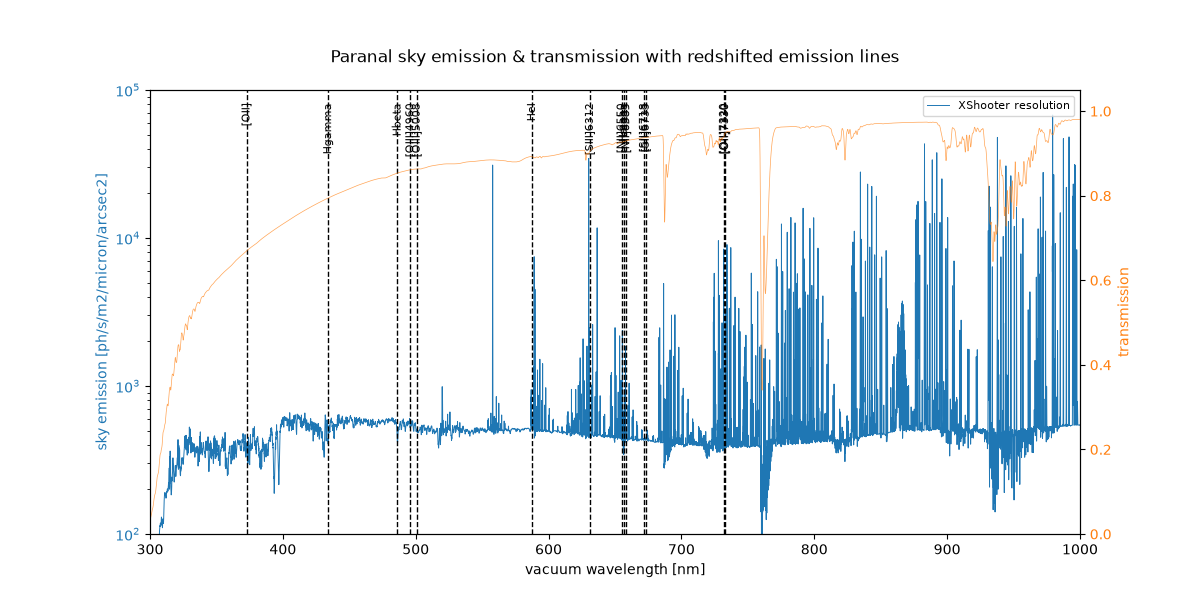

In [7]:
%matplotlib widget
import numpy as np
import ipywidgets as widgets
from astropy.convolution import Gaussian1DKernel, convolve

lam = a[1].data["lam"]  # vacuum wavelength, nm
flux = a[1].data["flux"]  # sky emission, ph/s/m2/micron/arcsec2
trans = a[1].data["trans"]  # sky transmission

# rest-frame vacuum wavelengths in nm -- edit/add lines here
emission_lines_nm = {
    "Lyman-alpha": 121.567,
    "[OII]": 372.742,
    "Hgamma": 434.168,
    "Hbeta": 486.268,
    "[OIII]4960": 496.030,
    "[OIII]5008": 500.824,
    "HeI": 587.562,
    "[SIII]6312": 631.2,
    "[NII]6550": 654.986,
    "Halpha": 656.461,
    "[NII]6585": 658.527,
    "[SII]6718": 671.829,
    "[SII]6733": 673.267,
    "[OII]7320": 732.0,
    "[OII]7330": 733.0,
}

# skytable.fits is sampled at fixed resolving power (SKYMODEL.WAVELENGTH.RESOLUTION header keyword)
R_skycalc = 20000

# XShooter arms (1.0" slit): wavelength coverage [nm] and nominal resolving power
xshooter_arms = [
    ("UVB", 300.0, 559.5, 5100),
    ("VIS", 559.5, 1024.0, 8800),
    ("NIR", 1024.0, 2480.0, 5300),
]

# fixed-R grid => resolution element is a constant number of pixels, so convolve per-arm with a Gaussian kernel
flux_xshooter = np.full_like(flux, np.nan)
for _, lam_min, lam_max, R_inst in xshooter_arms:
    mask = (lam >= lam_min) & (lam < lam_max)
    sigma_pix = (R_skycalc / R_inst) / (2 * np.sqrt(2 * np.log(2)))
    kernel = Gaussian1DKernel(stddev=sigma_pix)
    flux_xshooter[mask] = convolve(flux[mask], kernel, boundary="extend")
    # trans[mask] = convolve(trans[mask], kernel, boundary="extend")

trans_smooth = convolve(trans, Gaussian1DKernel(stddev=10), boundary="extend")

fig, ax_flux = plt.subplots(figsize=(12, 6))
ax_trans = ax_flux.twinx()

# ax_flux.plot(lam, flux, color="tab:blue", lw=0.4, alpha=0.3, label="native (R=20000)")
ax_flux.plot(lam, flux_xshooter, color="tab:blue", lw=0.7, label="XShooter resolution")
ax_flux.legend(loc="upper right", fontsize=8)
ax_flux.set_ylim(100, 100000)
ax_flux.set_yscale("log")
ax_flux.set_xlabel("vacuum wavelength [nm]")
ax_flux.set_ylabel("sky emission [ph/s/m2/micron/arcsec2]", color="tab:blue")
ax_flux.tick_params(axis="y", labelcolor="tab:blue")

# ax_trans.plot(lam, trans, color="tab:orange", lw=0.5, alpha=0.7)
ax_trans.plot(lam, trans_smooth, color="tab:orange", lw=0.5, alpha=0.7)
ax_trans.set_ylabel("transmission", color="tab:orange")
ax_trans.tick_params(axis="y", labelcolor="tab:orange")
ax_trans.set_ylim(0, 1.05)
ax_trans.set_xlim(300, 1000)

ax_flux.set_title(
    "Paranal sky emission & transmission with redshifted emission lines", pad=20
)
fig.subplots_adjust(top=0.85)

line_artists = {}
for name, rest_nm in emission_lines_nm.items():
    vline = ax_flux.axvline(rest_nm, color="k", ls="--", lw=1)
    label = ax_flux.text(
        rest_nm,
        0.97,
        name,
        rotation=90,
        va="top",
        ha="center",
        transform=ax_flux.get_xaxis_transform(),
        fontsize=8,
    )
    line_artists[name] = (vline, label)


def update(z=0.0):
    for name, rest_nm in emission_lines_nm.items():
        obs_nm = rest_nm * (1 + z)
        vline, label = line_artists[name]
        vline.set_xdata([obs_nm, obs_nm])
        label.set_position((obs_nm, 0.97))
    fig.canvas.draw_idle()


z_slider = widgets.FloatSlider(
    value=0.0,
    min=0.0,
    max=0.5,
    step=0.0001,
    description="z",
    readout_format=".3f",
    continuous_update=True,
)
widgets.interactive(update, z=z_slider)
